# ***DSP MINI PROJECT***
***


# **Decoding Box Office Success: Hit or Flop Prediction using Data Analytics**
***




**DATASET USED: IMDB Movies Dataset (FROM KAGGLE)**

***















***PROJECT SUBMITTED BY:***   





***RIDDHI RATHI B2-B4-58***






**This project analyzes movie data to understand patterns and predict whether a movie will be a Hit or Flop using data analytics techniques.**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

from sklearn.cluster import KMeans
from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings("ignore")

## Data Understanding

In this step, we explore the dataset structure, data types, and statistical summary to understand the basic characteristics of the data.

In [ ]:
df = pd.read_csv("movies.csv")
df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


,IMDB_Rating,Meta_score,No_of_Votes
count,1000.000000,843.000000,1.000000e+03
mean,7.949300,77.971530,2.736929e+05
std,0.275491,12.376099,3.273727e+05
min,7.600000,28.000000,2.508800e+04
25%,7.700000,70.000000,5.552625e+04
50%,7.900000,79.000000,1.385485e+05
75%,8.100000,87.000000,3.741612e+05
max,9.300000,100.000000,2.343110e+06


In [ ]:
dfisnulled = df.isnull().sum()
print(dfisnulled)

Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64


In [ ]:
#drop null values
df.dropna(inplace=True)

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 997
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    714 non-null    object 
 1   Series_Title   714 non-null    object 
 2   Released_Year  714 non-null    object 
 3   Certificate    714 non-null    object 
 4   Runtime        714 non-null    object 
 5   Genre          714 non-null    object 
 6   IMDB_Rating    714 non-null    float64
 7   Overview       714 non-null    object 
 8   Meta_score     714 non-null    float64
 9   Director       714 non-null    object 
 10  Star1          714 non-null    object 
 11  Star2          714 non-null    object 
 12  Star3          714 non-null    object 
 13  Star4          714 non-null    object 
 14  No_of_Votes    714 non-null    int64  
 15  Gross          714 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 94.8+ KB


,IMDB_Rating,Meta_score,No_of_Votes
count,714.000000,714.000000,7.140000e+02
mean,7.937115,77.158263,3.561348e+05
std,0.293278,12.401144,3.539011e+05
min,7.600000,28.000000,2.522900e+04
25%,7.700000,70.000000,9.600975e+04
50%,7.900000,78.000000,2.366025e+05
75%,8.100000,86.000000,5.077922e+05
max,9.300000,100.000000,2.343110e+06


## Univariate Analysis

We analyze individual features like IMDB rating using histograms and boxplots to understand their distribution and detect outliers.

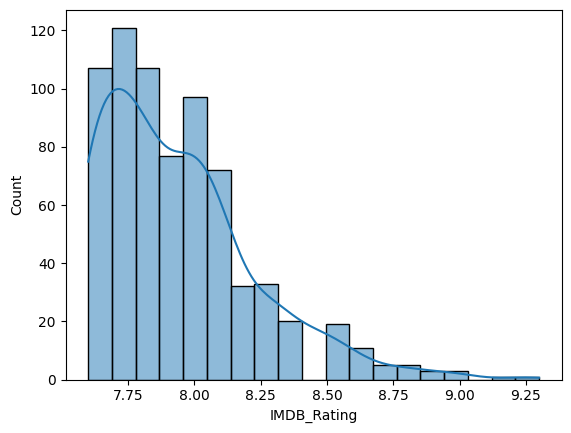

In [ ]:
sns.histplot(df['IMDB_Rating'], kde=True)
plt.show()



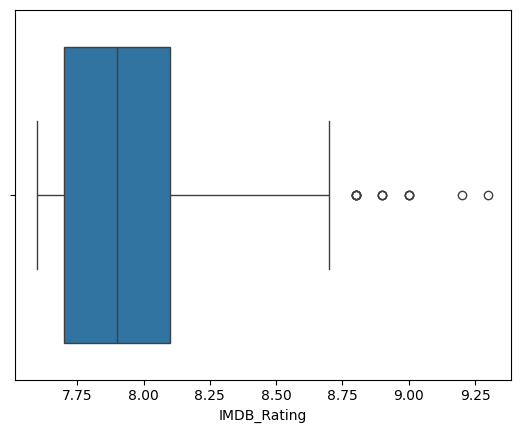

In [ ]:
sns.boxplot(x=df['IMDB_Rating'])
plt.show()

##Bivariate & Multivariate Analysis

We study relationships between variables such as rating and meta score, and analyze patterns across different genres.

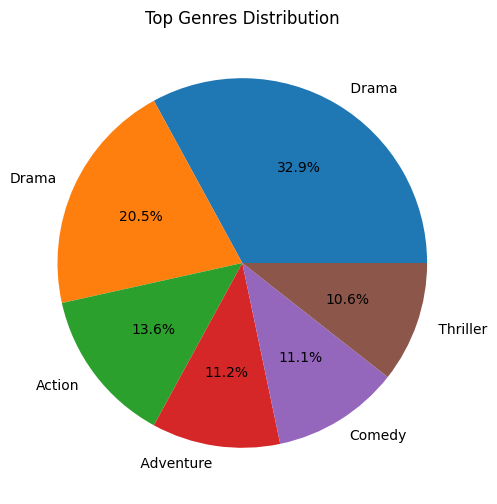

In [ ]:
genre_series = df['Genre'].str.split(',', expand=True).stack()
genre_counts = genre_series.value_counts().head(6)
plt.figure(figsize=(6,6))
plt.pie(genre_counts, labels=genre_counts.index, autopct='%1.1f%%')
plt.title("Top Genres Distribution")
plt.show()

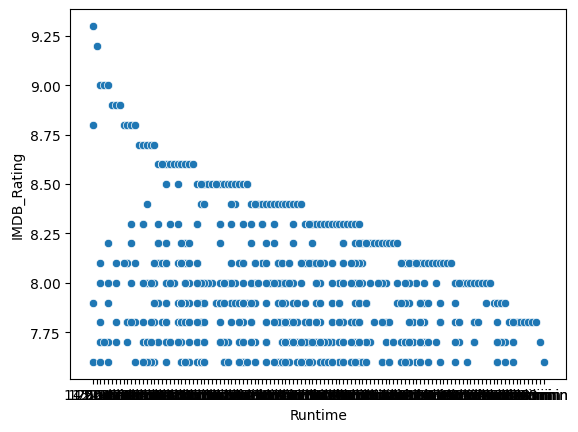

In [ ]:
sns.scatterplot(x=df['Runtime'], y=df['IMDB_Rating'])
plt.show()

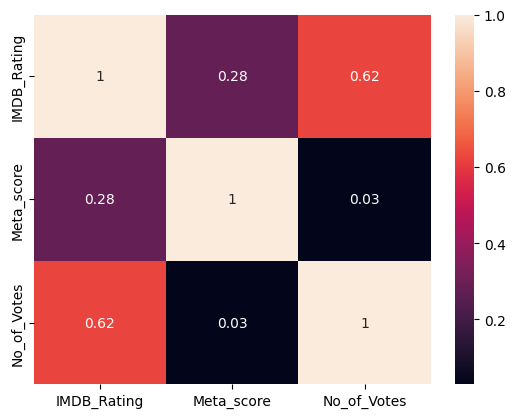

In [ ]:
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.show()

##Data Transformation

We encode categorical variables and normalize numerical features to make the dataset suitable for machine learning algorithms.

In [ ]:
scaler = StandardScaler()
df[['Meta_score']] = scaler.fit_transform(df[['Meta_score']])

In [ ]:
df = df.loc[:, ~df.columns.duplicated()]
df.fillna(df.median(numeric_only=True), inplace=True)

In [ ]:
le = LabelEncoder()
df['Genre_encoded'] = le.fit_transform(df['Genre'])



In [ ]:
df['status'] = df['IMDB_Rating'].apply(lambda x: 1 if x >= 8.5 else 0)

print(df['status'].value_counts()) #target

status
0    666
1     48
Name: count, dtype: int64


##Prediction Model

We build a classification model using Logistic Regression to predict whether a movie is a Hit or Flop based on its features.

In [ ]:
X = df[['Meta_score', 'Genre_encoded']] #feature selection
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# balanced model
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [ ]:

#aacuracy percent
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.5664335664335665


Accuracy: 0.5664335664335665


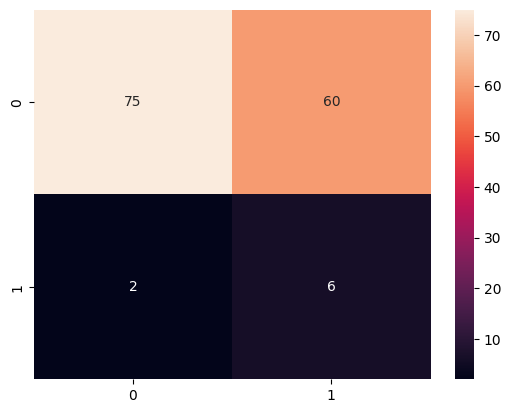

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

##Clustering

We group movies into clusters based on similarity using K-Means clustering to identify patterns in the dataset.

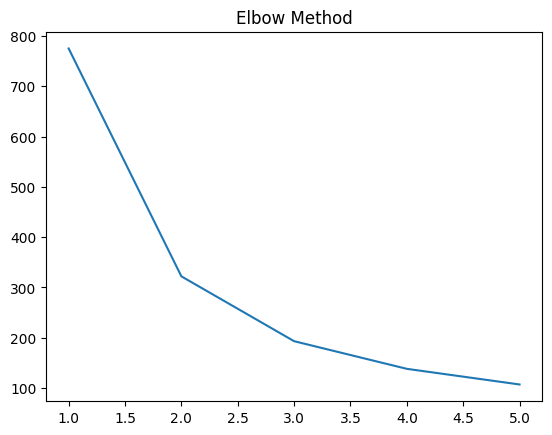

In [ ]:
X_cluster = df[['IMDB_Rating', 'Meta_score']]

wcss = []
for i in range(1,6):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,6), wcss)
plt.title("Elbow Method")
plt.show()

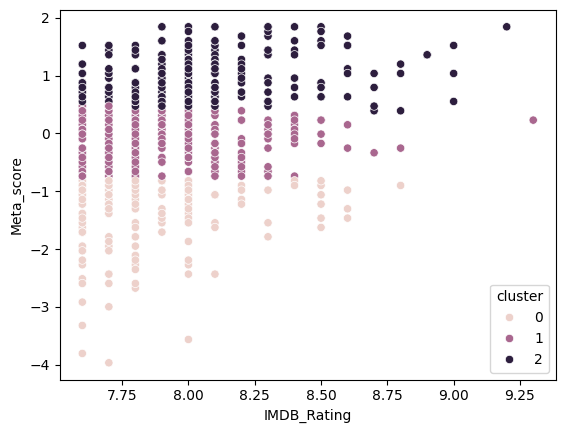

In [ ]:
kmeans = KMeans(n_clusters=3)
df['cluster'] = kmeans.fit_predict(X_cluster)

sns.scatterplot(x=df['IMDB_Rating'], y=df['Meta_score'], hue=df['cluster'])
plt.show()

##GUI Implementation (Gradio)

An interactive interface is created using Gradio to allow users to input movie details and get real-time predictions.

In [ ]:
import gradio as gr
import numpy as np

# ✅ Use only trained genres
valid_genres = list(le.classes_)

# ✅ FINAL FUNCTION (SAFE + NO ERROR)
def predict_movie(meta_score, genre):
    try:
        # check genre
        if genre not in valid_genres:
            return "⚠️ Genre not recognized"

        # encode genre
        genre_encoded = le.transform([genre])[0]

        # scale meta score
        scaled_meta = scaler.transform([[float(meta_score)]])

        # input (NO IMDB rating → realistic model)
        input_data = np.array([[scaled_meta[0][0], float(genre_encoded)]])

        # prediction
        pred = model.predict(input_data)

        return "🎬 HIT ✅" if pred[0] == 1 else "❌ FLOP"

    except Exception as e:
        return f"Error: {str(e)}"


# 🎨 UI Styling
css = """
body {
    background: linear-gradient(135deg, #1f1c2c, #928dab);
}
.gradio-container {
    font-family: 'Segoe UI', sans-serif;
}
"""

# 🧱 UI Layout
with gr.Blocks(css=css) as demo:

    gr.Markdown("""
    # 🎬 Movie Hit/Flop Predictor
    ### Predict movie success using Data Analytics
    """)

    with gr.Row():
        with gr.Column():
            meta = gr.Number(label="🎯 Meta Score")

            genre = gr.Dropdown(
                choices=valid_genres,   # ✅ FIXED
                label="🎭 Genre"
            )

            btn = gr.Button("🚀 Predict", variant="primary")

        with gr.Column():
            output = gr.Textbox(label="🎬 Prediction Result")

    btn.click(fn=predict_movie, inputs=[meta, genre], outputs=output)

    gr.Markdown("✨ Built using Gradio | Data Analytics Project")

# 🚀 Launch
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5e926656c15c2ba725.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Prediction Conditions:

The model predicts whether a movie is a Hit or Flop based on the following conditions:

- A movie is classified as a **Hit** when it has:
  
  - High Meta Score (above average range)
  - Favorable genre patterns based on training data

- A movie is classified as a **Flop** when it has:
  
  - Low Meta Score
  - Weak feature combination compared to successful movies

The prediction is made using Logistic Regression, which learns patterns from historical data and applies them to new inputs.

## Conclusion

In this project, we explored the complete data analytics pipeline using a movie dataset. We learned how to perform exploratory data analysis (EDA) to understand data patterns, distributions, and relationships between features such as IMDb rating, meta score, and genre.

We implemented data preprocessing techniques including handling missing values, encoding categorical variables, and feature scaling to prepare the dataset for modeling.

Further, we applied multiple analytical techniques such as association rule mining, classification using Logistic Regression, and clustering using K-Means to extract meaningful insights and patterns from the data.

Finally, we developed an interactive user interface using Gradio, which allows real-time prediction of whether a movie will be a Hit or Flop based on user inputs.

Overall, this project helped us understand how data analysis and machine learning can be combined to build practical and user-friendly applications.